# Multi-Frame Drop deformation Fourier analysis

In [2]:
import os
import glob
import itertools
from skimage import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from fourier_functions import analyze_frame_fourier_complete, track_droplet_template

In [4]:


# ==========================================
# 1. INPUT PARAMETERS BY USER
# ==========================================
folder_path = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7'
format = '*.tif'
output_folder = '/Users/lucaasinari/Desktop/Tesi ESPCI/script_rheoflu/results/cell_constriction7'
os.makedirs(output_folder, exist_ok=True)

#image_path = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/cell0000002.tif'

first_frame = 500       
last_frame = 540
step = 20      

#Template informations
image_path_referenceframe = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7011809.tif'
y_center = 97 
x_center = 139
radius = 18
gray_img1 = cv2.cvtColor(cv2.imread(image_path_referenceframe), cv2.COLOR_BGR2GRAY)
template = gray_img1[int(y_center - radius) : int(y_center + radius), int(x_center - radius) : int(x_center + radius)]
plt.figure()
plt.imshow(template, cmap='gray')
plt.title('Template')
plt.axis('off') # Nasconde gli assi
plt.show()

plt.figure()
plt.imshow(gray_img1, cmap='gray')
plt.title('reference frame')
plt.axis('off') # Nasconde gli assi
plt.show()

[ WARN:0@39.179] global loadsave.cpp:278 findDecoder imread_('/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7011809.tif'): can't open/read file: check file path/integrity


error: OpenCV(5.0.0) /Users/macmini_16g/GHA-Actions-Opencv-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
image_files = []

for i in range(first_frame, last_frame):
    frame_number_str = str(i).zfill(6)
    filename = f"constriction7{frame_number_str}.tif"
    full_path = os.path.join(folder_path, filename)
    image_files.append(full_path)

print(f"Percorsi generati: {len(image_files)}")
for f in image_files[:5]:
    print(f)


Percorsi generati: 40
/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7000500.tif
/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7000501.tif
/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7000502.tif
/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7000503.tif
/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7000504.tif


In [ ]:
diff = last_frame - first_frame
rest = diff % step

if rest != 0:
        print(f"⚠️ AVVISO: Il range di frame selezionato ({diff} frame) non è un multiplo dello step ({step}).")
        print(f"   Verranno saltati gli ultimi {rest} frame finali all'interno del range.\n")

selected_frames = image_files[::step]

print(f"Trovate {len(image_files)} immagini totali.")
print(f"Verranno analizzati {len(selected_frames)} frame.\n")

Trovate 40 immagini totali.
Verranno analizzati 20 frame.



In [ ]:
# ==========================================
# 3. IMAGES ANALYSIS (con salvataggio output)
# ==========================================
import csv
import json

# --- Crea cartella di output ---
output_folder = '/Users/lucaasinari/Desktop/Tesi ESPCI/script_rheoflu/results'
os.makedirs(output_folder, exist_ok=True)

av_radius_a0 = []
shift_ord1 = []
amp_ord2 = []
amp_ord3 = []
amp_ord4 = []
coeff_ord2 = []
coeff_ord3 = []
coeff_ord4 = []
frames_analizzati = []

# Definisci il contorno iniziale (init) per il primo frame
h_roi, w_roi = template.shape
radius_start = min(h_roi, w_roi) / 2 - 1
s = np.linspace(0, 2*np.pi, 400)
x = h_roi//2 + radius_start * np.sin(s)
y = w_roi//2 + radius_start * np.cos(s)
init = np.array([x, y]).T

for cicle_index, img_path in enumerate(selected_frames):
    file_name = os.path.basename(img_path)
    abolute_frame = first_frame + (cicle_index * step)
        
    print(f"► Analyzing Frame {abolute_frame} ({file_name})...")
    img = io.imread(img_path)

    # Percorso per salvare l'immagine del tracking
    tracking_save_path = os.path.join(output_folder, f"tracking_frame_{abolute_frame}.png")

    found, center, ROI, confidence = track_droplet_template(
        img, 
        template, 
        threshold=0.5, 
        plot_result=False,
        save_path=tracking_save_path
    )

    if found:
        # Percorso per salvare il grafico del profilo di Fourier
        profile_save_path = os.path.join(output_folder, f"profile_frame_{abolute_frame}.png")

        a0, a1, b1, a2, b2, a3, b3, a4, b4, c1, c2, c3, c4, contour_estratto = analyze_frame_fourier_complete(
            img=ROI, 
            init_contour=init, 
            sigma=3,
            alpha=1.5,
            beta=10.0,
            w_edge=7.0,
            w_line=0.0,
            plot_profile=True,
            frame_number=abolute_frame,
            save_path=profile_save_path
        )
    
        av_radius_a0.append(a0)
        coeff_ord2.append(a2)
        coeff_ord3.append(a3)
        coeff_ord4.append(a4)
        shift_ord1.append(c1)
        amp_ord2.append(c2)
        amp_ord3.append(c3)
        amp_ord4.append(c4)
        frames_analizzati.append(abolute_frame)  
    
        #init = contour_estratto #faster with this!
    else:
        print(f"⚠️ Frame {abolute_frame} saltato: goccia non trovata o troppo deformata! (confidenza: {confidence:.2f})")

print("\n✅ Sequence completed")

# ==========================================
# 4. SALVATAGGIO RISULTATI
# ==========================================

# --- Salvataggio CSV ---
csv_path = os.path.join(output_folder, 'fourier_results.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['frame', 'a0', 'a2', 'a3', 'a4', 'c1', 'c2', 'c3', 'c4'])
    for i in range(len(frames_analizzati)):
        writer.writerow([
            frames_analizzati[i],
            av_radius_a0[i],
            coeff_ord2[i],
            coeff_ord3[i],
            coeff_ord4[i],
            shift_ord1[i],
            amp_ord2[i],
            amp_ord3[i],
            amp_ord4[i],
        ])
print(f"✅ Dati CSV salvati in: {csv_path}")

# --- Salvataggio JSON (con metadati per ricreare i grafici) ---
json_path = os.path.join(output_folder, 'fourier_results.json')
results_dict = {
    'metadata': {
        'folder_path': folder_path,
        'first_frame': first_frame,
        'last_frame': last_frame,
        'step': step,
        'template_info': {
            'reference_frame': image_path_referenceframe,
            'y_center': y_center,
            'x_center': x_center,
            'radius': radius,
        }
    },
    'data': {
        'frames': frames_analizzati,
        'a0': av_radius_a0,
        'a2': coeff_ord2,
        'a3': coeff_ord3,
        'a4': coeff_ord4,
        'c1': shift_ord1,
        'c2': amp_ord2,
        'c3': amp_ord3,
        'c4': amp_ord4,
    }
}
with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2)
print(f"✅ Metadati JSON salvati in: {json_path}")


► Analyzing Frame 500 (constriction7000500.tif)...
► Analyzing Frame 502 (constriction7000502.tif)...
► Analyzing Frame 504 (constriction7000504.tif)...
► Analyzing Frame 506 (constriction7000506.tif)...
► Analyzing Frame 508 (constriction7000508.tif)...
► Analyzing Frame 510 (constriction7000510.tif)...
► Analyzing Frame 512 (constriction7000512.tif)...
► Analyzing Frame 514 (constriction7000514.tif)...
► Analyzing Frame 516 (constriction7000516.tif)...
► Analyzing Frame 518 (constriction7000518.tif)...
► Analyzing Frame 520 (constriction7000520.tif)...
► Analyzing Frame 522 (constriction7000522.tif)...
► Analyzing Frame 524 (constriction7000524.tif)...
► Analyzing Frame 526 (constriction7000526.tif)...
► Analyzing Frame 528 (constriction7000528.tif)...
► Analyzing Frame 530 (constriction7000530.tif)...
► Analyzing Frame 532 (constriction7000532.tif)...
► Analyzing Frame 534 (constriction7000534.tif)...
► Analyzing Frame 536 (constriction7000536.tif)...
► Analyzing Frame 538 (constric

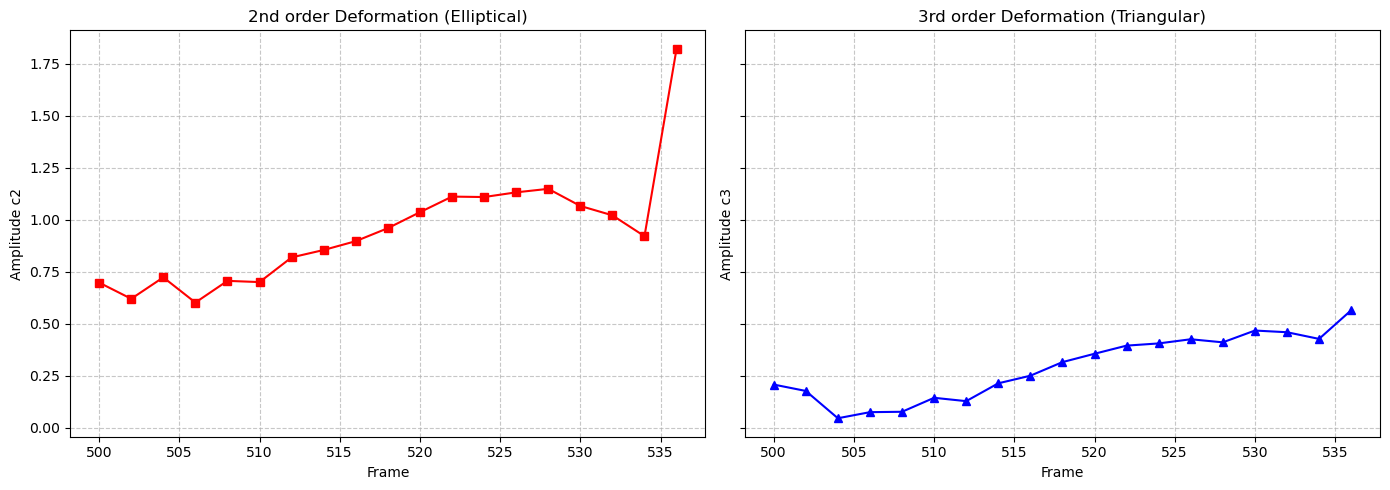

In [ ]:
# ----------------------------------------------------
# DEFORMATION-TIME PLOTS (a2 - a3)
# ----------------------------------------------------
asse_temporale = np.arange(first_frame, last_frame, step)
asse = asse_temporale[:len(amp_ord2)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.plot(asse, amp_ord2, marker='s', color='red')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Amplitude c2')
ax1.set_title('2nd order Deformation (Elliptical)')
ax1.grid(True, linestyle='--', alpha=0.7)
#ax1.set_ylim(-1.4, 1) 

ax2.plot(asse, amp_ord3, marker='^', color='blue')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Amplitude c3')
ax2.set_title('3rd order Deformation (Triangular)')
ax2.grid(True, linestyle='--', alpha=0.7)
#ax2.set_ylim(-1, 1)

plt.tight_layout()
plt.show()


# TEST

Calcolo della traiettoria sfumata su 20 frame in corso...


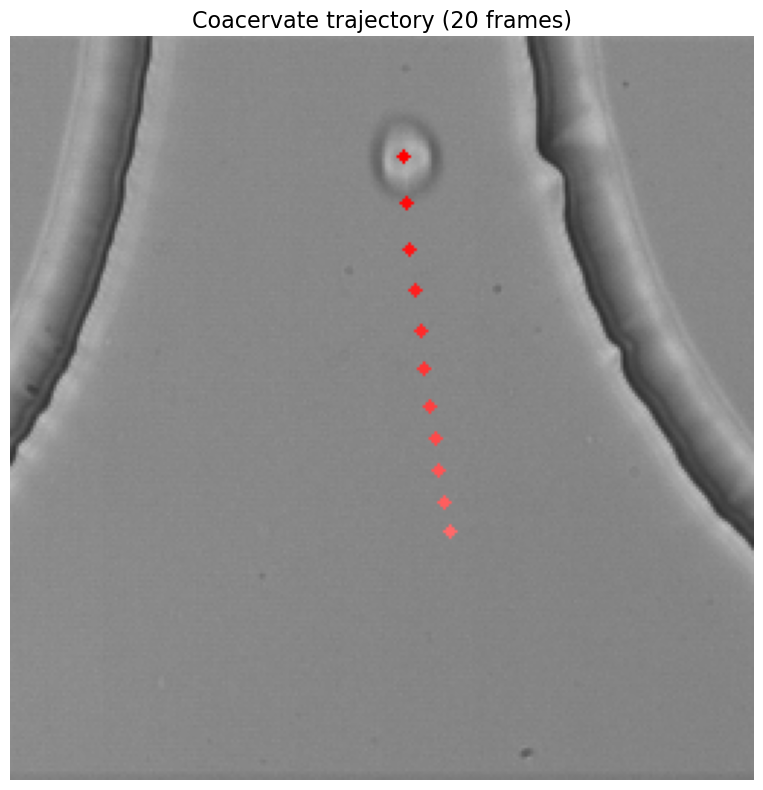

In [ ]:
# ----------------------------------------------------
# VISUALIZZAZIONE TRAIETTORIA SU PRIMO FRAME (CON SFUMATURA DI COLORE)
# ----------------------------------------------------
import matplotlib.pyplot as plt
from skimage import io
import cv2
import numpy as np

# 1. Carica il primo frame come base per il disegno
image_path_referenceframe = selected_frames[0]
img_primo = io.imread(image_path_referenceframe)

# Convertiamo in RGB per supportare i colori
if img_primo.ndim == 2:
    img_traj = cv2.cvtColor(img_primo, cv2.COLOR_GRAY2RGB)
else:
    img_traj = img_primo.copy()

h, w = template.shape[:2]
threshold = 0.8
N_frames = len(selected_frames)

print(f"Calcolo della traiettoria sfumata su {N_frames} frame in corso...")

# 2. Cicla con 'enumerate' per sapere l'indice (idx) di ogni frame
for idx, img_path in enumerate(selected_frames):
    img_curr = io.imread(img_path)
    
    if img_curr.ndim == 3:
        gray = cv2.cvtColor(img_curr, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_curr.copy()
        
    result = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    
    if max_val >= threshold:
        x_center = max_loc[0] + (w // 2)
        y_center = max_loc[1] + (h // 2)
        
        # --- COLORE SFUMATO---
        # progress andrà da 0.0 (primo frame) a 1.0 (ultimo frame)
        progress = idx / max(1, N_frames - 1)
        
        # Il Canale Rosso (R) è sempre al massimo (255)
        # Il Verde (G) e il Blu (B) salgono gradualmente da 0 a 200 
        # Risultato: Rosso scuro -> Rosso normale -> Rosso chiaro / Rosato
        R = 255
        G = int(progress * 200)
        B = int(progress * 200)
        
        # Disegna il puntino col colore calcolato
        cv2.circle(img_traj, (x_center, y_center), radius=2, color=(R, G, B), thickness=-1)

# 3. Plot finale
plt.figure(figsize=(10, 8))
plt.imshow(img_traj)
plt.title(f"Coacervate trajectory ({N_frames} frames)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


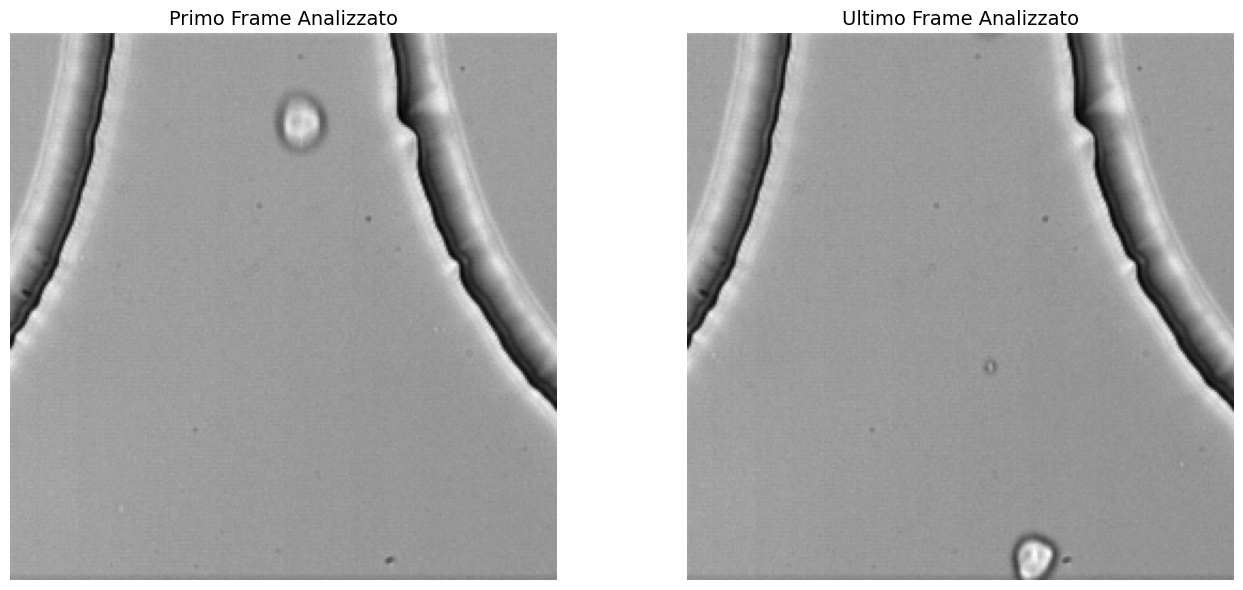

In [ ]:
# ----------------------------------------------------
# VISUALIZZAZIONE PRIMO E ULTIMO FRAME
# ----------------------------------------------------
import matplotlib.pyplot as plt
from skimage import io

image_path_referenceframe = selected_frames[0]
ultimo_frame_path = selected_frames[-1]

img_primo = io.imread(image_path_referenceframe)
img_ultimo = io.imread(ultimo_frame_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(img_primo, cmap="gray")
ax1.set_title(f"Primo Frame Analizzato", fontsize=14)
ax1.axis("off")

ax2.imshow(img_ultimo, cmap="gray")
ax2.set_title(f"Ultimo Frame Analizzato", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------
# BAR PLOTS FOR A2 AND A3 (ALL FRAMES)
# ----------------------------------------------------
"""
import math

num_frames = len(av_radius_a0)
cols = 5
rows = math.ceil(num_frames / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))

if num_frames > 1:
    axes = axes.flatten()
else:
    axes = [axes]
    
labels = ['a2\n(2nd harmonic)', 'a3\n(3rd harmonic)']

for i in range(num_frames):
    ax = axes[i]
    
    valori = [coeff_ord2[i], coeff_ord3[i]]   
    
    # Creiamo le barre
    ax.bar(labels, valori, color=['lightcoral', 'lightblue'], edgecolor='black', alpha=0.8)
    
    # Troviamo il valore assoluto più grande per calcolare le giuste proporzioni
    abs_max = max(abs(v) for v in valori) if any(valori) else 1
    margine = abs_max * 0.2  # 20% di margine
    
    # Scriviamo i numeri: sopra se positivi, sotto se negativi
    for j, valore in enumerate(valori):
        if valore >= 0:
            ax.text(j, valore + (margine * 0.2), f"{valore:.2f}", 
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
        else:
            ax.text(j, valore - (margine * 0.2), f"{valore:.2f}", 
                    ha='center', va='top', fontweight='bold', fontsize=9)
        
    ax.set_title(f"Frame {i+1}")
    
    # Adattiamo i limiti dell'asse Y per includere la barra più bassa e quella più alta
    lim_min = min(0, min(valori) - margine)
    lim_max = max(0, max(valori) + margine)
    ax.set_ylim(lim_min, lim_max)
    
    # Aggiungiamo una linea nera fissa sullo zero
    ax.axhline(0, color='black', linewidth=1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(num_frames, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""


'\nimport math\n\nnum_frames = len(av_radius_a0)\ncols = 5\nrows = math.ceil(num_frames / cols)\nfig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))\n\nif num_frames > 1:\n    axes = axes.flatten()\nelse:\n    axes = [axes]\n\nlabels = [\'a2\n(2nd harmonic)\', \'a3\n(3rd harmonic)\']\n\nfor i in range(num_frames):\n    ax = axes[i]\n\n    valori = [coeff_ord2[i], coeff_ord3[i]]   \n\n    # Creiamo le barre\n    ax.bar(labels, valori, color=[\'lightcoral\', \'lightblue\'], edgecolor=\'black\', alpha=0.8)\n\n    # Troviamo il valore assoluto più grande per calcolare le giuste proporzioni\n    abs_max = max(abs(v) for v in valori) if any(valori) else 1\n    margine = abs_max * 0.2  # 20% di margine\n\n    # Scriviamo i numeri: sopra se positivi, sotto se negativi\n    for j, valore in enumerate(valori):\n        if valore >= 0:\n            ax.text(j, valore + (margine * 0.2), f"{valore:.2f}", \n                    ha=\'center\', va=\'bottom\', fontweight=\'bold\', font

In [ ]:
# ----------------------------------------------------
# # BAR PLOTS FOR C1 --> A4 (ALL FRAMES)
# ----------------------------------------------------
"""
import math
num_frames = len(av_radius_a0)
cols = 5
rows = math.ceil(num_frames / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
if num_frames > 1:
    axes = axes.flatten()
else:
    axes = [axes]
labels = ['c1\n(1° ord)', 'c2\n(2° ord)', 'c3\n(3° ord)', 'c4\n(4° ord)']

for i in range(num_frames):
    ax = axes[i]
    
    valori = [shift_ord1[i], amp_ord2[i], amp_ord3[i], amp_ord4[i]]   
    ax.bar(labels, valori, color='coral', edgecolor='black', alpha=0.8)
    massimo = max(valori) if max(valori) > 0 else 1
    
    for j, valore in enumerate(valori):
        ax.text(j, valore + (massimo * 0.05), f"{valore:.2f}", 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
        
    ax.set_title(f"Frame {i+1}")
    ax.set_ylim(0,2.2) # massimo * 1.3) # Lascia il 30% di spazio sopra
    ax.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(num_frames, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""


'\nimport math\nnum_frames = len(av_radius_a0)\ncols = 5\nrows = math.ceil(num_frames / cols)\nfig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))\nif num_frames > 1:\n    axes = axes.flatten()\nelse:\n    axes = [axes]\nlabels = [\'c1\n(1° ord)\', \'c2\n(2° ord)\', \'c3\n(3° ord)\', \'c4\n(4° ord)\']\n\nfor i in range(num_frames):\n    ax = axes[i]\n\n    valori = [shift_ord1[i], amp_ord2[i], amp_ord3[i], amp_ord4[i]]   \n    ax.bar(labels, valori, color=\'coral\', edgecolor=\'black\', alpha=0.8)\n    massimo = max(valori) if max(valori) > 0 else 1\n\n    for j, valore in enumerate(valori):\n        ax.text(j, valore + (massimo * 0.05), f"{valore:.2f}", \n                ha=\'center\', va=\'bottom\', fontweight=\'bold\', fontsize=9)\n\n    ax.set_title(f"Frame {i+1}")\n    ax.set_ylim(0,2.2) # massimo * 1.3) # Lascia il 30% di spazio sopra\n    ax.grid(axis=\'y\', linestyle=\'--\', alpha=0.7)\n\nfor i in range(num_frames, len(axes)):\n    fig.delaxes(axes[i])\n\nplt

In [ ]:
# ----------------------------------------------------
# PLOT avarage radius
# ----------------------------------------------------
"""
plt.figure(figsize=(10,5))
# Mettiamo 'frames_analizzati' sull'asse X
plt.plot(frames_analizzati, av_radius_a0, marker='o', linestyle='-', color='blue')
plt.xlabel('Numero Frame Reale')
plt.ylabel('Raggio Medio a0')
plt.grid(True)
plt.show()
"""

"\nplt.figure(figsize=(10,5))\n# Mettiamo 'frames_analizzati' sull'asse X\nplt.plot(frames_analizzati, av_radius_a0, marker='o', linestyle='-', color='blue')\nplt.xlabel('Numero Frame Reale')\nplt.ylabel('Raggio Medio a0')\nplt.grid(True)\nplt.show()\n"

Frame 20: Goccia NON trovata (sotto threshold).


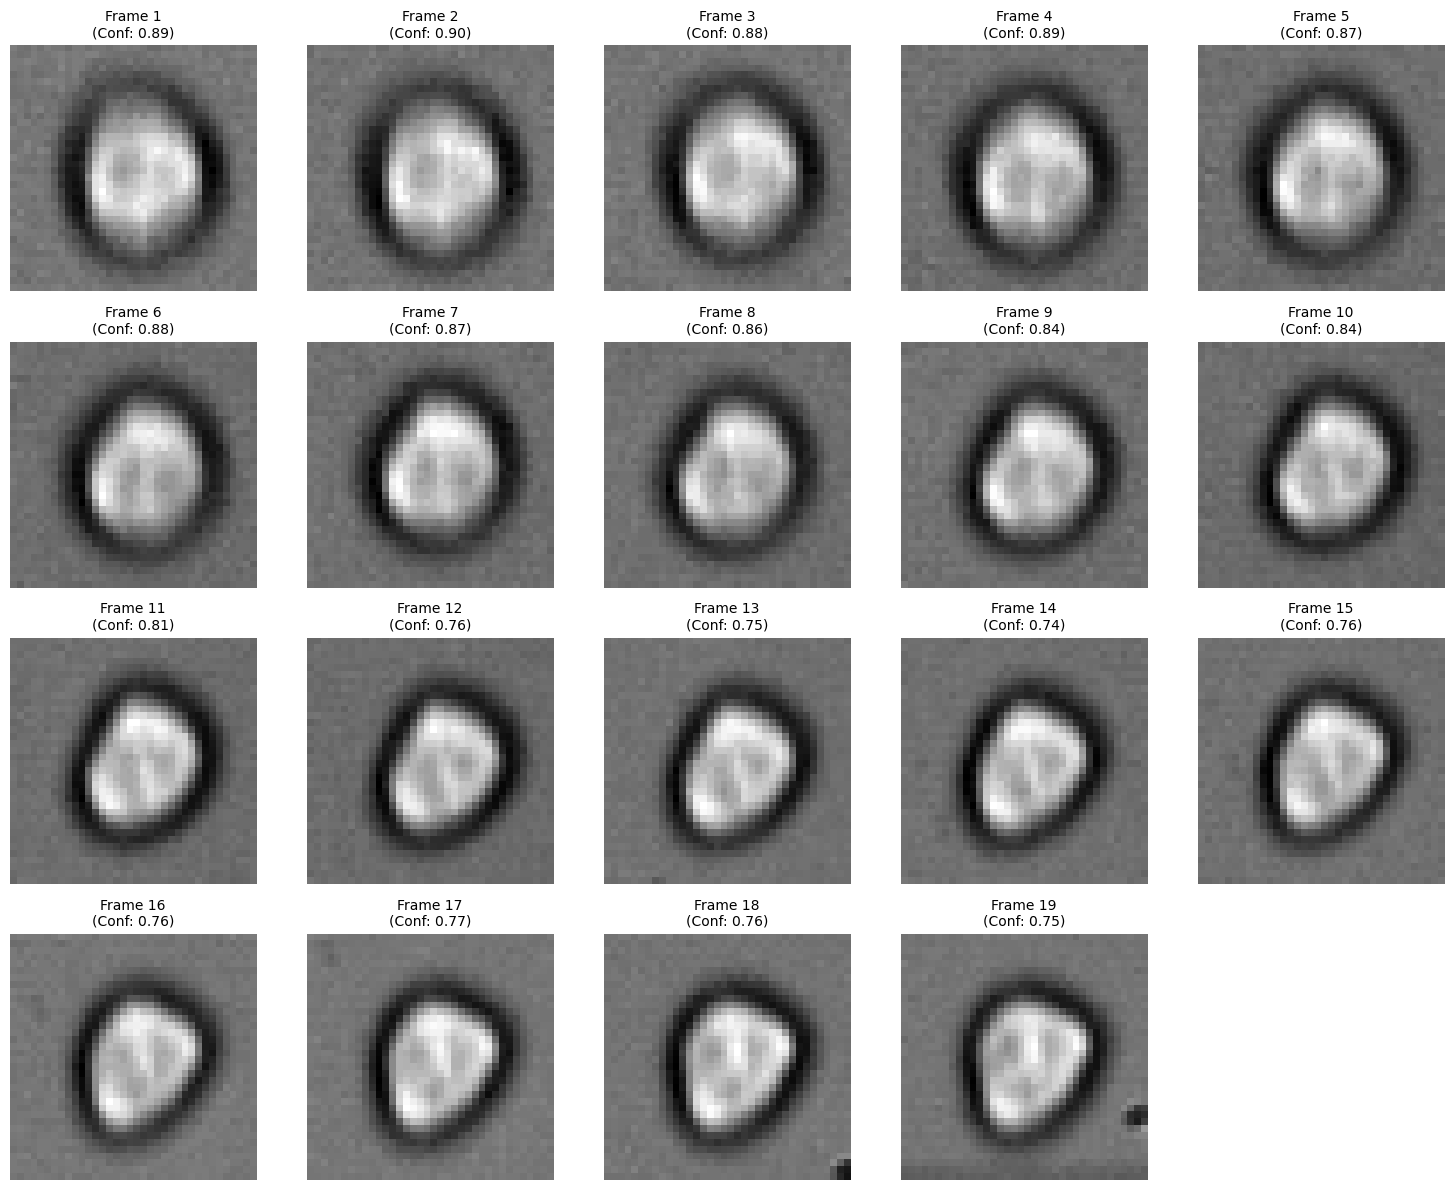

In [ ]:
# ----------------------------------------------------
# VISUALIZATION OF ALL THE ROI
# ----------------------------------------------------
import math

roi_list = []
frame_titles = []

# Ripercorriamo velocemente le immagini analizzate
for i, img_path in enumerate(selected_frames):
    img = io.imread(img_path)
    
    # La funzione restituisce: trovato, centro, ROI, affidabilità
    found, center, ROI, confidence = track_droplet_template(img, template, threshold=0.60, plot_result=False)
    
    if found:
        roi_list.append(ROI)
        frame_titles.append(f"Frame {i+1}\n(Conf: {confidence:.2f})")
    else:
        print(f"Frame {i+1}: Goccia NON trovata (sotto threshold).")

num_rois = len(roi_list)

# Disegniamo la griglia se abbiamo trovato almeno una ROI
if num_rois > 0:
    cols = 5
    rows = math.ceil(num_rois / cols)
    
    # Creiamo la figura (ogni grafico sarà circa 3x3 pollici)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    
    if num_rois > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
        
    for i in range(num_rois):
        ax = axes[i]
        ax.imshow(roi_list[i], cmap='gray')
        ax.set_title(frame_titles[i], fontsize=10)
        ax.axis('off')  # Nascondiamo i numeri degli assi x e y per pulizia
        
    # Eliminiamo gli eventuali riquadri extra rimasti vuoti
    for i in range(num_rois, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna ROI trovata da poter visualizzare.")
